# Chapter 13 — Neural Networks and Deep Learning

This notebook accompanies **Chapter 13** of *Inference in Statistical Modelling and Machine Learning*.

---

### Key ideas

- A **neuron** computes $\phi(b + \boldsymbol{w}^\top \boldsymbol{x})$: a weighted sum of inputs, a bias, and a non-linear activation $\phi$.
- Familiar methods — linear regression, logistic regression, multinomial logistic regression — are special cases of one- or two-layer neural networks.
- **Hidden layers** allow a network to learn intermediate representations. The universal approximation theorem guarantees that a single wide hidden layer can approximate any continuous function.
- Networks are trained by **gradient descent** on a loss function. Mini-batching and the Adam optimiser make this practical at scale.
- **Convolutional networks (CNNs)** exploit spatial structure: each filter scans the image with shared weights, making the learned features translation-invariant.
- CNNs outperform MLPs of comparable size on image tasks, because their architectural bias toward local features helps them generalise.
- **Overfitting** occurs when training loss keeps falling while validation loss rises; **early stopping** and **dropout** are two remedies.

**Note on compute.** Training the MLP takes roughly 1–2 minutes and the CNN roughly 5–7 minutes on a CPU. Run all cells from top to bottom.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
rng = np.random.default_rng(42)

---
## 1 · Neurons and activation functions

A single neuron in a neural network computes
$$
  y = \phi\!\left(b + \boldsymbol{w}^\top \boldsymbol{x}\right),
$$
where $\boldsymbol{w}$ is the neuron's weight vector, $b$ is its bias, $\phi$ is its (fixed) **activation function**, and $\boldsymbol{x}$ is its vector of inputs.

Two common activation functions are:

- **ReLU** (rectified linear unit): $\phi(z) = \max(0, z)$.  Applied in hidden layers — computationally cheap, and its gradient is 0 or 1 everywhere, which avoids the vanishing-gradient problem that plagues saturating functions in deep networks.
- **Sigmoid** $\sigma(z) = (1 + e^{-z})^{-1}$.  Maps any real number to $(0,1)$; used in binary classification output neurons.

**Softmax** is a related but distinct idea.  It is *not* an activation function in the sense above, because it does not act on a single pre-activation — it acts on the entire pre-activation *vector* of an output layer:
$$
  \text{softmax}(\boldsymbol{z})_i = \frac{e^{z_i}}{\sum_j e^{z_j}}.
$$
Each output depends on *all* the pre-activations through the normalising denominator, so a softmax layer cannot be decomposed into independent neurons each applying the same scalar $\phi$.  It is best thought of as a fixed, parameter-free transformation applied to the output layer as a whole, turning raw class scores into a proper probability distribution.

> **Book link — §13.1 and §13.3.2.**

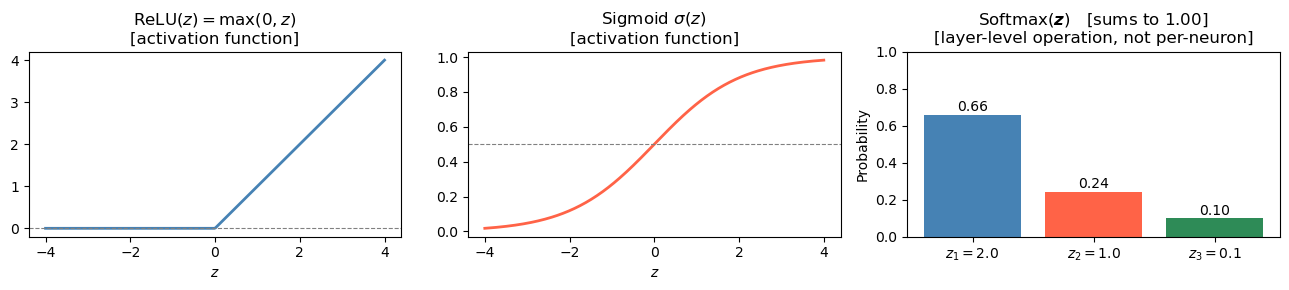

In [28]:
z = np.linspace(-4, 4, 300)
relu    = np.maximum(z, 0)
sigmoid = 1.0 / (1.0 + np.exp(-z))

# softmax on a concrete 3-vector
z_vec = np.array([2.0, 1.0, 0.1])
e_vec = np.exp(z_vec - z_vec.max())
sm    = e_vec / e_vec.sum()

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(z, relu, color='steelblue', lw=2)
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].set_xlabel('$z$')
axes[0].set_title('ReLU$(z) = \\max(0, z)$\n[activation function]')

axes[1].plot(z, sigmoid, color='tomato', lw=2)
axes[1].axhline(0.5, color='grey', lw=0.8, ls='--')
axes[1].set_xlabel('$z$')
axes[1].set_title('Sigmoid $\\sigma(z)$\n[activation function]')

bars = axes[2].bar(range(3), sm, color=['steelblue', 'tomato', 'seagreen'])
axes[2].set_xticks(range(3))
axes[2].set_xticklabels([f'$z_{i+1}={z_vec[i]}$' for i in range(3)])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Probability')
axes[2].set_title(f'Softmax$(\\boldsymbol{{z}})$   [sums to {sm.sum():.2f}]\n[layer-level operation, not per-neuron]')
for bar, val in zip(bars, sm):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

ReLU is piecewise linear with a kink at zero; it is cheap to evaluate and gradient-friendly in deep networks.  Sigmoid saturates for large $|z|$, which slows learning when gradients become tiny.  The third panel shows softmax on a concrete score vector: the largest score receives most of the probability mass, but all classes get a positive share.  Note that the three bars cannot be read off independently — changing any one $z_i$ shifts the entire output.

> **Book link — §13.2–13.3.** A single linear neuron implements ordinary least-squares linear regression; a single sigmoid neuron implements binary logistic regression; a single softmax *layer* implements multinomial logistic regression. These familiar methods are therefore special cases of simple neural networks.

---
## 2 · Training an MLP on MNIST digits

MNIST is a dataset of 70,000 handwritten digit images ($28 \times 28$ greyscale pixels, 10 classes).  We use 50,000 for training, 10,000 for validation, and 10,000 as a held-out test set.

Our **multilayer perceptron (MLP)** has the architecture
$$
  784 \;\xrightarrow{\text{ReLU}}\; 128 \;\xrightarrow{\text{ReLU}}\; 64 \;\xrightarrow{\text{softmax}}\; 10.
$$
It treats the $28 \times 28$ image as a flat vector of 784 pixel values with no geometric structure. Every input pixel is connected to every neuron in the first hidden layer.

We train with the **Adam** optimiser (learning rate $10^{-3}$, mini-batch size 64) and cross-entropy loss for 10 epochs.

> **Book link — §13.5–13.6.** Section 13.5 defines deep networks; Section 13.6 motivates mini-batch gradient descent and the Adam algorithm.

Train: 50,000   Val: 10,000   Test: 10,000


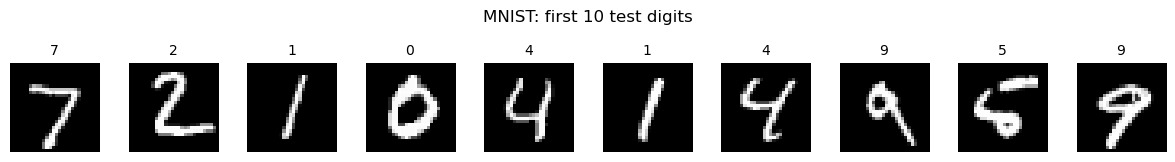

In [29]:
_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download=True fetches the data on first run; subsequent runs use the cached copy
_full_train = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=_transform)
test_set    = torchvision.datasets.MNIST('./data', train=False, download=True, transform=_transform)

train_set, val_set = random_split(
    _full_train, [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=64,  shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_set,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False)

print(f'Train: {len(train_set):,}   Val: {len(val_set):,}   Test: {len(test_set):,}')

# show a sample row of digits
fig, axes = plt.subplots(1, 10, figsize=(12, 1.5))
for ax, i in zip(axes, range(10)):
    img, label = test_set[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST: first 10 test digits', y=1.05)
plt.tight_layout()
plt.show()

In [30]:
class MLP(nn.Module):
    def __init__(self, hidden=(128, 64), dropout_p=0.0):
        super().__init__()
        sizes = [784] + list(hidden) + [10]
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:           # hidden layers get ReLU (+ optional dropout)
                layers.append(nn.ReLU())
                if dropout_p > 0:
                    layers.append(nn.Dropout(dropout_p))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


def run_epoch(model, loader, optimizer=None):
    """One pass over loader; if optimizer given, also updates weights."""
    criterion = nn.CrossEntropyLoss()
    model.train(optimizer is not None)
    total, n = 0.0, 0
    with torch.set_grad_enabled(optimizer is not None):
        for X, y in loader:
            logits = model(X)
            loss   = criterion(logits, y)
            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(y)
            n     += len(y)
    return total / n


def fit(model, train_loader, val_loader, n_epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_hist, val_hist = [], []
    for _ in range(n_epochs):
        train_hist.append(run_epoch(model, train_loader, opt))
        val_hist.append(run_epoch(model, val_loader))
    return train_hist, val_hist


def accuracy(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            correct += (model(X).argmax(1) == y).sum().item()
    return correct / len(loader.dataset)


def n_params(model):
    return sum(p.numel() for p in model.parameters())

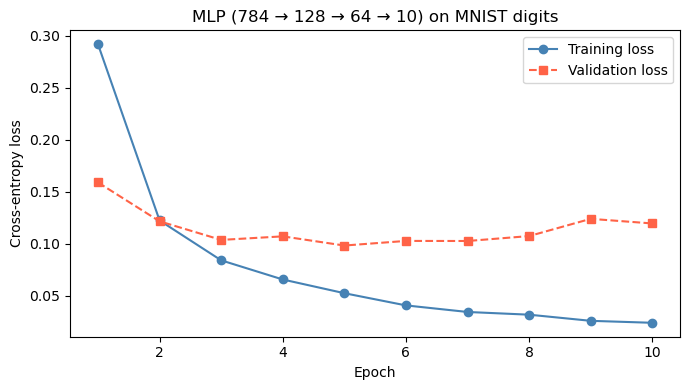

MLP parameters : 109,386
MLP test accuracy: 0.9719


In [31]:
torch.manual_seed(42)
mlp = MLP()
train_hist_mlp, val_hist_mlp = fit(mlp, train_loader, val_loader, n_epochs=10)

epochs = range(1, 11)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_hist_mlp, 'o-', color='steelblue', label='Training loss')
ax.plot(epochs, val_hist_mlp,   's--', color='tomato',    label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('MLP (784 \u2192 128 \u2192 64 \u2192 10) on MNIST digits')
ax.legend()
plt.tight_layout()
plt.show()

print(f'MLP parameters : {n_params(mlp):,}')
print(f'MLP test accuracy: {accuracy(mlp, test_loader):.4f}')

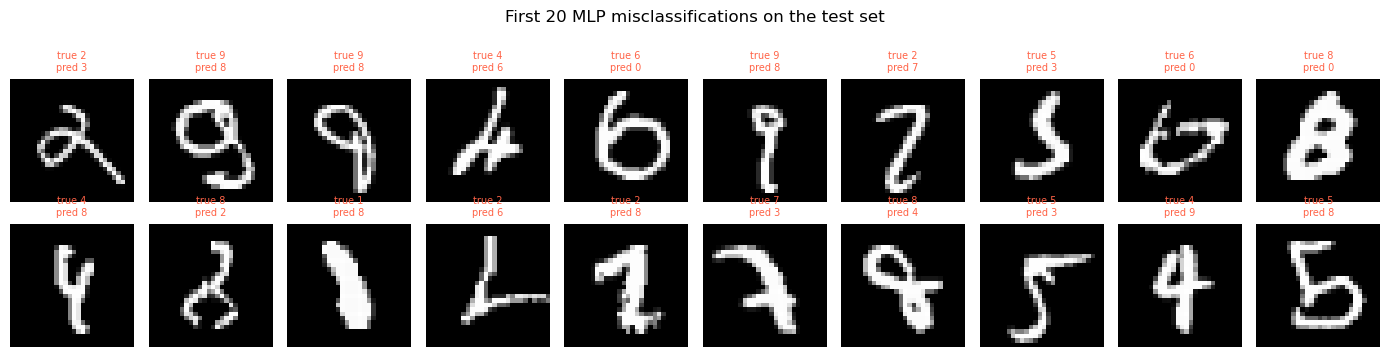

In [32]:
# collect the first 20 misclassified test examples
mlp.eval()
wrong_imgs, wrong_true, wrong_pred = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        preds = mlp(X).argmax(1)
        mask  = preds != y
        wrong_imgs.append(X[mask])
        wrong_true.extend(y[mask].tolist())
        wrong_pred.extend(preds[mask].tolist())
        if len(wrong_true) >= 20:
            break

wrong_imgs = torch.cat(wrong_imgs)[:20]

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_imgs[i].squeeze(), cmap='gray')
    ax.set_title(f'true {wrong_true[i]}\npred {wrong_pred[i]}', fontsize=7, color='tomato')
    ax.axis('off')
plt.suptitle('First 20 MLP misclassifications on the test set', y=1.02)
plt.tight_layout()
plt.show()

Training loss falls steadily throughout. Validation loss falls quickly in the first few epochs but then levels off and begins to creep upward — a mild sign that the model is starting to fit noise rather than signal. The gap is small here, but it would widen with more epochs or a larger model.

Some of the misclassified digits are genuinely ambiguous. Others are errors we would not expect a human to make, though we can usually `see what the neural network was thinking' --- a badly-drawn 8 can look a *little* like a 2, etc. One way to reduce errors of the second kind is to bake a richer representation of spatial structure into the network architecture. That is the focus of the next section.

---
## 3 · Convolutional networks: exploiting spatial structure

### Motivation

An MLP's first hidden layer connects **every** input pixel to **every** neuron.  This is expensive and ignores an important prior: nearby pixels are correlated, and the same local patterns (edges, corners, textures) can appear anywhere in the image.

A **convolutional layer** instead assigns each neuron responsibility for a small local patch (e.g. $3 \times 3$ pixels).  All neurons in the same layer share the same weights — a single **filter** or **kernel**.  This enforces two inductive biases:

1. **Local connectivity**: neurons only see a small neighbourhood.
2. **Weight sharing**: the same feature detector is applied everywhere (*translation invariance*).

The output of a convolutional layer is a **feature map** — a spatial map of where the filter's pattern fires.  A **max-pooling** layer then summarises each $2 \times 2$ block of a feature map by its maximum, halving the spatial resolution.

> **Book link — §13.8.** Section 13.8.2 defines convolutional filters and feature maps in detail; §13.8.3 walks through the CNN architecture we use below.

### Architecture

We use the same architecture as Figure 13.16 in the text:

$$
\underbrace{28{\times}28}_{\text{input}} \to
\underbrace{\text{Conv}(8,3{\times}3)}_{80 \text{ params}} \to
\underbrace{\text{MaxPool}}_{} \to
\underbrace{\text{Conv}(16,3{\times}3)}_{1168 \text{ params}} \to
\underbrace{\text{MaxPool}}_{} \to
\underbrace{\text{FC}(128)}_{100480 \text{ params}} \to
\underbrace{\text{Softmax}(10)}_{1290 \text{ params}}
$$

After two rounds of $2{\times}2$ max-pooling the feature maps are $7{\times}7$, giving $16 \times 7 \times 7 = 784$ inputs to the fully connected head.

In [33]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8,  16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(16 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))          # (B,1,28,28) -> (B,8,14,14)
        x = self.pool(F.relu(self.conv2(x)))          # (B,8,14,14) -> (B,16,7,7)
        x = F.relu(self.fc1(x.view(x.size(0), -1)))  # flatten then FC
        return self.fc2(x)

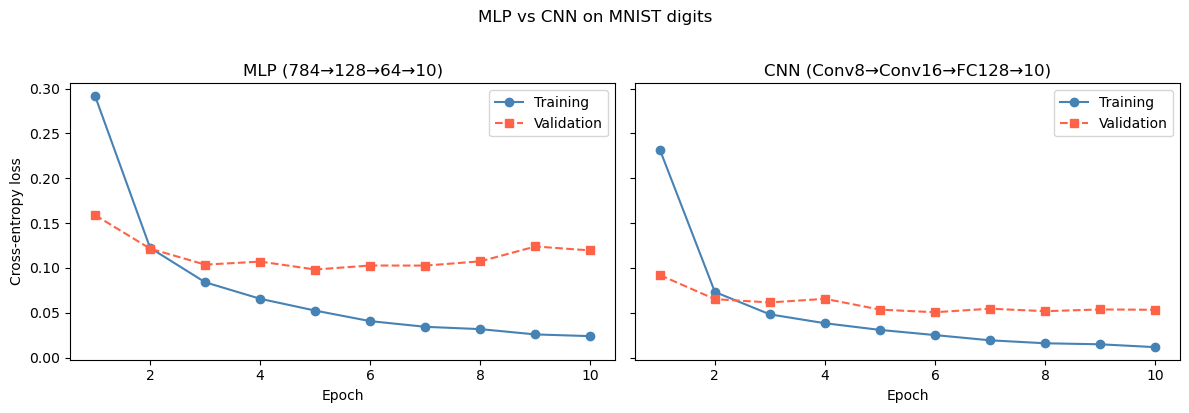

MLP  parameters: 109,386   test accuracy: 0.9719  (2.81% error)
CNN  parameters: 103,018   test accuracy: 0.9872  (1.28% error)


In [34]:
torch.manual_seed(42)
cnn = SimpleCNN()
train_hist_cnn, val_hist_cnn = fit(cnn, train_loader, val_loader, n_epochs=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, th, vh, title in zip(
    axes,
    [train_hist_mlp, train_hist_cnn],
    [val_hist_mlp,   val_hist_cnn],
    ['MLP (784\u2192128\u219264\u219210)', 'CNN (Conv8\u2192Conv16\u2192FC128\u219210)']
):
    ax.plot(epochs, th, 'o-',  color='steelblue', label='Training')
    ax.plot(epochs, vh, 's--', color='tomato',    label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel('Cross-entropy loss')
plt.suptitle('MLP vs CNN on MNIST digits', y=1.02)
plt.tight_layout()
plt.show()

mlp_acc = accuracy(mlp, test_loader)
cnn_acc = accuracy(cnn, test_loader)
print(f'MLP  parameters: {n_params(mlp):,}   test accuracy: {mlp_acc:.4f}  ({100*(1-mlp_acc):.2f}% error)')
print(f'CNN  parameters: {n_params(cnn):,}   test accuracy: {cnn_acc:.4f}  ({100*(1-cnn_acc):.2f}% error)')

The CNN achieves a meaningfully lower test error than the MLP — roughly halving the misclassification rate — despite having *fewer* parameters.  The CNN's architectural bias toward local, translation-invariant features helps it generalise: it cannot exploit arbitrary correlations between distant pixels, so it is less likely to memorise noise.

---
## 4 · What has the CNN learned?

### Convolutional filter kernels

The first convolutional layer has 8 filters, each with a $3 \times 3$ kernel.  We can visualise these kernels directly: positive weights (red) respond to bright pixels; negative weights (blue) respond to dark pixels.

> **Book link — §13.8.5.** The text visualises pre-activation maps for the Fashion MNIST CNN and discusses which filters correspond to interpretable features (vertical edges, horizontal edges, brightness detectors).

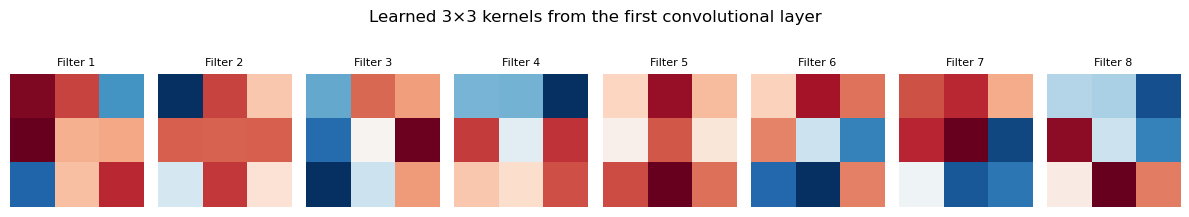

In [35]:
kernels = cnn.conv1.weight.data.squeeze(1).numpy()   # (8, 3, 3)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    vmax = np.abs(kernels[i]).max()
    ax.imshow(kernels[i], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned 3\u00d73 kernels from the first convolutional layer', y=1.08)
plt.tight_layout()
plt.show()

Some filters are interpretable as edge detectors or brightness detectors; others are harder to describe concisely.  Filter redundancy — where two filters look similar — is a known phenomenon in CNNs and does not necessarily indicate a flaw (see §13.8.5 of the text).

### Pre-activation maps

A more informative view is to feed an actual digit through the first convolutional layer and plot the resulting pre-activation maps — one per filter, showing which spatial locations each filter responds to most strongly.

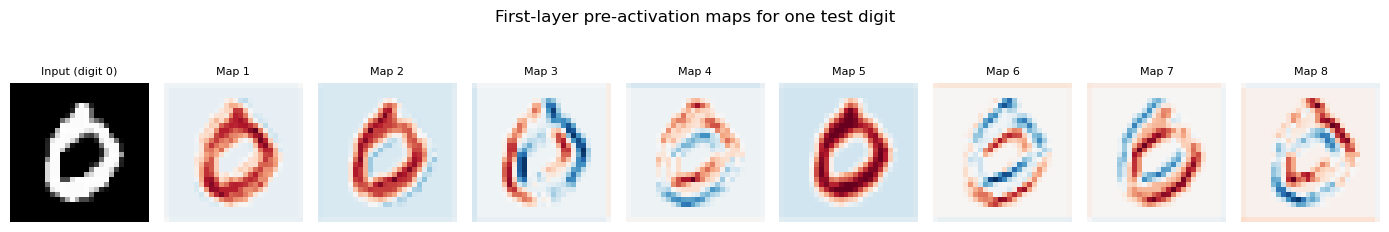

In [36]:
# pick a test image and run it through conv1 (before ReLU)
img, true_label = test_set[3]

cnn.eval()
with torch.no_grad():
    pre_act = cnn.conv1(img.unsqueeze(0)).squeeze(0).numpy()   # (8, 28, 28)

fig, axes = plt.subplots(1, 9, figsize=(14, 2.2))

axes[0].imshow(img.squeeze(), cmap='gray')
axes[0].set_title(f'Input (digit {true_label})', fontsize=8)
axes[0].axis('off')

for i, ax in enumerate(axes[1:]):
    vmax = np.abs(pre_act[i]).max()
    ax.imshow(pre_act[i], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Map {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('First-layer pre-activation maps for one test digit', y=1.08)
plt.tight_layout()
plt.show()

Each pre-activation map highlights the parts of the digit where that filter's pattern is found.  Some maps light up along strokes (edge detectors); others respond to the interior or background.  Filters that looked similar as raw kernels can produce different maps on a particular input.

---
## Exercises

### Exercise 1 — Overfitting and early stopping

When a model is too expressive relative to the amount of training data, it can memorise the training set while generalising poorly — **overfitting**.  A reliable symptom is training loss continuing to fall while validation loss levels off or rises.  The simplest remedy is **early stopping**: halt training when the validation loss has not improved for some number of consecutive epochs (the *patience*).

(a) To make overfitting visible quickly, train a larger MLP — architecture $784 \to 512 \to 256 \to 10$ — on a subset of **5,000** training examples for **30 epochs**.  Plot training and validation loss on the same axes and identify visually where the model starts to overfit.

(b) Implement an `EarlyStopping` class with a `patience` parameter.  Re-run the same training with your stopping rule (patience = 5).  Report the epoch at which training stops and compare test accuracy to the 30-epoch run.

> **Book link — §13.7.** Early stopping is described as an example of implicit regularisation.

In [37]:
# ── Exercise 1 — your code here ───────────────────────────────────────────


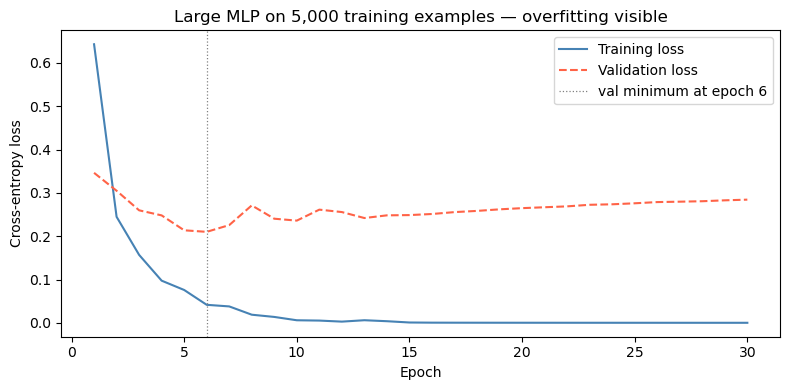

Early stopping triggered at epoch 9  (val minimum was epoch 6)
Test accuracy — early stopping : 0.9496
Test accuracy — 30 epochs      : 0.9533


In [38]:
# ── Exercise 1 — solution ─────────────────────────────────────────────────

# (a) train a large MLP on a small subset to expose overfitting
small_loader = DataLoader(
    Subset(train_set, list(range(5000))),
    batch_size=64, shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

torch.manual_seed(0)
mlp_big = MLP(hidden=(512, 256))
big_train, big_val = fit(mlp_big, small_loader, val_loader, n_epochs=30)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 31), big_train, color='steelblue', label='Training loss')
ax.plot(range(1, 31), big_val,   color='tomato',    linestyle='--', label='Validation loss')
best_ep = int(np.argmin(big_val)) + 1
ax.axvline(best_ep, color='grey', linewidth=0.9, linestyle=':', label=f'val minimum at epoch {best_ep}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Large MLP on 5,000 training examples — overfitting visible')
ax.legend()
plt.tight_layout()
plt.show()

# (b) early stopping
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best     = float('inf')
        self.wait     = 0

    def step(self, val_loss):
        """Returns True when training should stop."""
        if val_loss < self.best:
            self.best = val_loss
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience

torch.manual_seed(0)
mlp_es  = MLP(hidden=(512, 256))
opt_es  = torch.optim.Adam(mlp_es.parameters(), lr=1e-3)
es      = EarlyStopping(patience=5)
stop_ep = None

for ep in range(1, 31):
    run_epoch(mlp_es, small_loader, opt_es)
    vl = run_epoch(mlp_es, val_loader)
    if es.step(vl):
        stop_ep = ep
        break

print(f'Early stopping triggered at epoch {stop_ep}  (val minimum was epoch {best_ep})')
print(f'Test accuracy — early stopping : {accuracy(mlp_es,  test_loader):.4f}')
print(f'Test accuracy — 30 epochs      : {accuracy(mlp_big, test_loader):.4f}')

**Interpretation.**  With only 5,000 training examples the large MLP has enough capacity to memorise the training set: training loss continues to fall long after validation loss has bottomed out and started to climb.  Early stopping recovers a model close to the validation minimum without ever evaluating test data, giving better test accuracy than the fully-trained 30-epoch model.

---
### Exercise 2 — Dropout

**Dropout** (Srivastava et al., 2014) is an explicit regularisation strategy: during each training forward pass, each neuron's activation is independently set to zero with probability $p$, forcing the network to learn redundant representations.  At test time all neurons are active and their outputs are scaled by $(1-p)$.

Add dropout ($p = 0.3$) after each ReLU in the §2 MLP (use the `dropout_p` argument of `MLP`).  Train for 10 epochs on the full training set and plot training and validation loss curves alongside those of the undropped MLP from §2.  Comment on the effect on the train/validation gap and on final test accuracy.

> **Book link — §13.14.** Exercise 13.14 in the text discusses weight decay (ridge regularisation on weights) as another explicit regulariser; dropout is a complementary approach.

In [39]:
# ── Exercise 2 — your code here ───────────────────────────────────────────


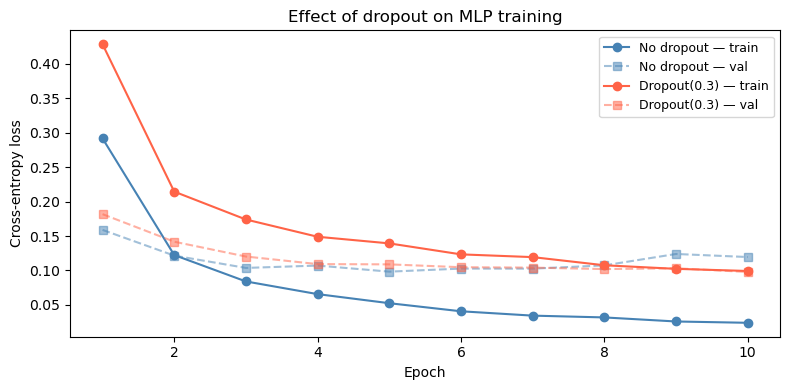

Without dropout — test accuracy: 0.9719
With dropout    — test accuracy: 0.9776


In [40]:
# ── Exercise 2 — solution ─────────────────────────────────────────────────
torch.manual_seed(42)
mlp_drop = MLP(dropout_p=0.3)
train_drop, val_drop = fit(mlp_drop, train_loader, val_loader, n_epochs=10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_hist_mlp, 'o-',  color='steelblue',           label='No dropout — train')
ax.plot(epochs, val_hist_mlp,   's--', color='steelblue', alpha=0.5, label='No dropout — val')
ax.plot(epochs, train_drop,     'o-',  color='tomato',               label='Dropout(0.3) — train')
ax.plot(epochs, val_drop,       's--', color='tomato',    alpha=0.5, label='Dropout(0.3) — val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Effect of dropout on MLP training')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Without dropout — test accuracy: {accuracy(mlp,      test_loader):.4f}')
print(f'With dropout    — test accuracy: {accuracy(mlp_drop, test_loader):.4f}')

**Interpretation.**  Dropout raises the training loss (the network is harder to train when neurons are randomly silenced) but typically reduces the train/validation gap — the hallmark of regularisation.  On MNIST digits, which is a relatively easy task, the accuracy improvement is modest; the effect is more pronounced on harder datasets where the baseline MLP overfits more severely.

---
### Exercise 3 — Confusion matrix

Aggregate test-set accuracy hides important information about *which* digits the CNN confuses.  A **confusion matrix** $C$ has $C_{ij}$ = number of test examples with true label $i$ that were predicted as class $j$.  Diagonal entries are correct predictions; off-diagonal entries are errors.

Compute and display the $10 \times 10$ confusion matrix for the trained CNN on the test set.  Then identify the three most common misclassified pairs and comment on whether they are visually plausible.

In [41]:
# ── Exercise 3 — your code here ───────────────────────────────────────────


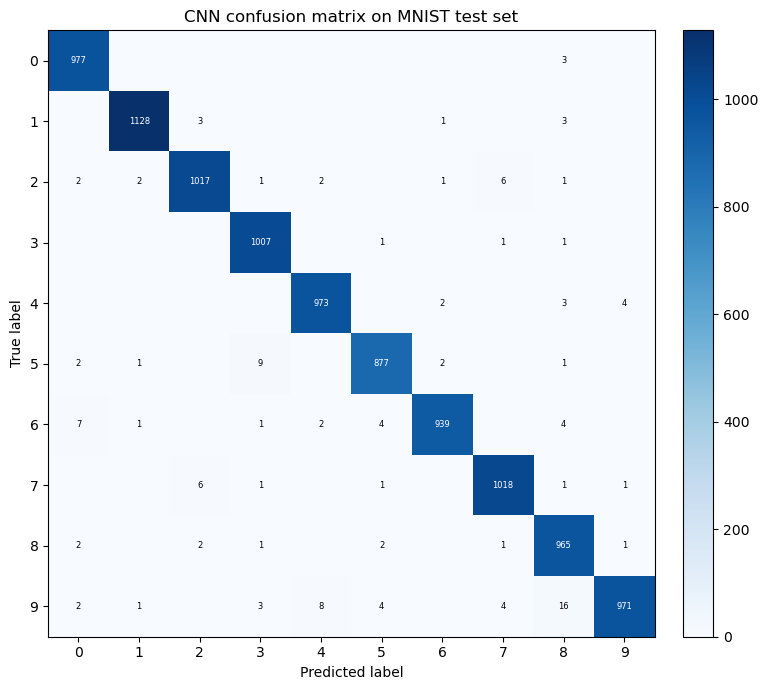

Top misclassifications (true → predicted, count):
  9 → 8 : 16
  5 → 3 : 9
  9 → 4 : 8
  6 → 0 : 7
  7 → 2 : 6


In [42]:
# ── Exercise 3 — solution ─────────────────────────────────────────────────
cnn.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        all_preds.extend(cnn(X).argmax(1).numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('CNN confusion matrix on MNIST test set')
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=6,
                    color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

errors = sorted(
    [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j and cm[i, j] > 0],
    reverse=True
)
print('Top misclassifications (true \u2192 predicted, count):')
for count, true, pred in errors[:5]:
    print(f'  {true} \u2192 {pred} : {count}')

**Interpretation.**  The diagonal dominates: most digits are classified correctly.  The most common errors tend to involve pairs that share visual structure — for example, 9 and 8. These confusions primarily reflect genuine ambiguity in handwriting rather than a flaw in the model.